# UAV Landing Safety Assessment — SVM Classifier with Justification Report

**Objective:** Given a post-disaster satellite image, determine whether the depicted area is **safe**, a **caution zone**, or **unsafe** for UAV landing — and produce a human-readable justification report.

**Unit of analysis:** One image = one candidate landing zone.

**Safety labels** are derived from the existing building-damage annotations using an expert-defined risk heuristic (detailed in Section 3). No ground-truth UAV landing labels exist in this dataset; all verdicts are therefore model-inferred and should be validated by a human operator before acting on them.

---
| Class | Meaning | Heuristic basis |
|---|---|---|
| **Safe** | Area is structurally intact; landing is feasible | ≥70 % no-damage buildings AND low-risk disaster type AND <10 % destroyed |
| **Caution** | Partial damage or environmental hazard; proceed with care | Intermediate damage mix OR moderate-risk disaster |
| **Unsafe** | Active hazard or heavy structural collapse; do not land | ≥30 % destroyed/major-damage OR high-risk disaster type (flood, tsunami, volcano, earthquake) |

## 1. Setup & Imports

In [38]:
import os, json, re, warnings, textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image
from shapely import wkt as shapely_wkt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR  = Path(r'd:\ENGG2112Project\ClearedSet\post_disaster_split')
IMG_DIR   = BASE_DIR / 'images'
LABEL_DIR = BASE_DIR / 'labels'
REPORT_DIR = BASE_DIR / 'uav_reports'
REPORT_DIR.mkdir(exist_ok=True)

print('Images :', len(list(IMG_DIR.glob('*.png'))))
print('Labels :', len(list(LABEL_DIR.glob('*.json'))))
print('Reports will be saved to:', REPORT_DIR)

Images : 1866
Labels : 1866
Reports will be saved to: d:\ENGG2112Project\ClearedSet\post_disaster_split\uav_reports


## 2. Disaster Risk Taxonomy

We assign each disaster event a **risk tier** (1–3) that reflects its inherent UAV-landing hazard independently of structural damage:

| Tier | Meaning | Events |
|---|---|---|
| 1 – Low | Fire/smoke risk; ground mostly navigable | wildfire, socal-fire, santa-rosa-wildfire |
| 2 – Moderate | Wind debris, partial flooding | hurricane-matthew, hurricane-michael |
| 3 – High | Water saturation, debris fields, ground instability | hurricane-florence, hurricane-harvey, midwest-flooding, palu-tsunami, mexico-earthquake, guatemala-volcano |

In [39]:
# Disaster → (risk_tier, human_label, primary_hazard)
DISASTER_RISK = {
    'socal-fire'         : (1, 'Wildfire',          'smoke / ash'),
    'santa-rosa-wildfire': (1, 'Wildfire',          'smoke / ash'),
    'hurricane-matthew'  : (2, 'Hurricane',         'wind debris'),
    'hurricane-michael'  : (2, 'Hurricane',         'wind debris'),
    'hurricane-florence' : (3, 'Hurricane+Flooding','water / mud'),
    'hurricane-harvey'   : (3, 'Hurricane+Flooding','water / mud'),
    'midwest-flooding'   : (3, 'Flooding',          'water / mud'),
    'palu-tsunami'       : (3, 'Tsunami',           'water / debris'),
    'mexico-earthquake'  : (3, 'Earthquake',        'rubble / instability'),
    'guatemala-volcano'  : (3, 'Volcanic Eruption', 'ash / heat'),
}

SAFETY_LABELS = {0: 'Safe', 1: 'Caution', 2: 'Unsafe'}
SAFETY_COLORS = {0: '#4CAF50', 1: '#FFC107', 2: '#F44336'}

DAMAGE_ORDER = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

## 3. Feature Extraction — Image Level

Features serve two distinct roles — **label derivation** and **SVM input**. Mixing them causes data leakage.

### Used to DERIVE the safety label only (never fed to the SVM)
- `pct_no_damage`, `pct_severe`, `pct_destroyed` etc. — damage class proportions  
- `risk_tier` — disaster-type hazard tier (1–3)

These directly encode the labelling if/else rule. Feeding them to the model as features would mean the SVM just memorises the threshold, not anything about the imagery — producing artificially perfect scores.

### SVM input features (observable from sensor data alone)

**Building geometry** (count and footprint size from annotation polygons — *not* damage class)
- `n_buildings` — building density proxy
- `mean_building_area`, `std_building_area` — obstacle size statistics

**Environmental / visual features** (from image pixels)
- `mean_R/G/B`, `std_R/G/B` — channel statistics (detect water, fire, ash)
- `blue_dominance` — blue minus red channel mean (standing-water proxy)
- `brightness` — overall luminance
- `texture_roughness` — mean gradient magnitude (rubble = high roughness)
- `dark_fraction` — fraction of very dark pixels (water / shadowed debris)

**Sensor / acquisition metadata**
- `gsd`, `off_nadir_angle`, `sun_elevation` — image geometry

In [40]:
def shannon_entropy(counts):
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def image_visual_features(img_path: str, resize_to: int = 256) -> dict:
    """Extract visual features from the full satellite image."""
    img   = Image.open(img_path).convert('RGB').resize((resize_to, resize_to), Image.BILINEAR)
    arr   = np.array(img, dtype=np.float32) / 255.0   # (H, W, 3)

    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    grey = arr.mean(axis=2)

    # Gradient magnitude (roughness proxy)
    gy = np.diff(grey, axis=0)[:, :-1]
    gx = np.diff(grey, axis=1)[:-1, :]
    grad_mag = np.sqrt(gx**2 + gy**2)

    return {
        'mean_R'            : float(r.mean()),
        'mean_G'            : float(g.mean()),
        'mean_B'            : float(b.mean()),
        'std_R'             : float(r.std()),
        'std_G'             : float(g.std()),
        'std_B'             : float(b.std()),
        'blue_dominance'    : float(b.mean() - r.mean()),          # >0 → water signal
        'brightness'        : float(grey.mean()),
        'texture_roughness' : float(grad_mag.mean()),
        'dark_fraction'     : float((grey < 0.15).mean()),         # fraction of dark pixels
    }


def extract_image_record(json_path: Path, img_dir: Path) -> dict | None:
    """Parse one label file and return a feature dict for the whole image."""
    with open(json_path) as f:
        data = json.load(f)

    meta    = data.get('metadata', {})
    xy_list = data.get('features', {}).get('xy', [])

    img_name = meta.get('img_name', json_path.stem + '.png')
    img_path = img_dir / img_name
    if not img_path.exists():
        return None

    # --- Damage distribution ---
    dmg_counts = {d: 0 for d in DAMAGE_ORDER}
    building_areas = []

    for feat in xy_list:
        props   = feat.get('properties', {})
        subtype = props.get('subtype', '').strip()
        if subtype not in dmg_counts:
            continue
        dmg_counts[subtype] += 1

        try:
            geom = shapely_wkt.loads(feat.get('wkt', ''))
            if not geom.is_empty:
                b = geom.bounds
                building_areas.append((b[2]-b[0]) * (b[3]-b[1]))
        except Exception:
            pass

    n_total  = max(sum(dmg_counts.values()), 1)
    cnts_arr = np.array([dmg_counts[d] for d in DAMAGE_ORDER], dtype=float)

    pct_no_damage = dmg_counts['no-damage']  / n_total
    pct_minor     = dmg_counts['minor-damage']/ n_total
    pct_major     = dmg_counts['major-damage']/ n_total
    pct_destroyed = dmg_counts['destroyed']   / n_total
    pct_severe    = pct_major + pct_destroyed          # combined heavy damage

    # --- Safety label derivation ---
    disaster   = meta.get('disaster', 'unknown')
    risk_tier, risk_label, primary_hazard = DISASTER_RISK.get(
        disaster, (2, 'Unknown', 'unknown hazard')
    )

    if pct_severe >= 0.30 or risk_tier == 3:
        safety = 2   # Unsafe
    elif pct_no_damage >= 0.70 and risk_tier == 1 and pct_destroyed < 0.10:
        safety = 0   # Safe
    else:
        safety = 1   # Caution

    # --- Visual features ---
    vis = image_visual_features(str(img_path))

    record = {
        # Identifiers
        'img_name'         : img_name,
        'img_path'         : str(img_path),
        'disaster'         : disaster,
        'risk_label'       : risk_label,
        'primary_hazard'   : primary_hazard,
        # Raw counts (for report)
        'n_no_damage'      : dmg_counts['no-damage'],
        'n_minor'          : dmg_counts['minor-damage'],
        'n_major'          : dmg_counts['major-damage'],
        'n_destroyed'      : dmg_counts['destroyed'],
        'n_buildings'      : n_total,
        # Features for SVM
        'pct_no_damage'    : pct_no_damage,
        'pct_minor'        : pct_minor,
        'pct_major'        : pct_major,
        'pct_destroyed'    : pct_destroyed,
        'pct_severe'       : pct_severe,
        'damage_entropy'   : shannon_entropy(cnts_arr),
        'mean_building_area': float(np.mean(building_areas)) if building_areas else 0.0,
        'std_building_area' : float(np.std(building_areas))  if building_areas else 0.0,
        'risk_tier'        : float(risk_tier),
        'gsd'              : float(meta.get('gsd', 0)),
        'off_nadir_angle'  : float(meta.get('off_nadir_angle', 0)),
        'sun_elevation'    : float(meta.get('sun_elevation', 0)),
        # Visual
        **vis,
        # Label
        'safety_label'     : safety,
    }
    return record


print('Function definitions ready.')

Function definitions ready.


In [41]:
print('Parsing all label files …')
records = []
json_files = sorted(LABEL_DIR.glob('*.json'))

for i, jf in enumerate(json_files):
    rec = extract_image_record(jf, IMG_DIR)
    if rec is not None:
        records.append(rec)
    if (i + 1) % 300 == 0:
        print(f'  … {i+1}/{len(json_files)} done')

df = pd.DataFrame(records)
print(f'\nTotal images parsed: {len(df)}')
print(df['safety_label'].map(SAFETY_LABELS).value_counts())

Parsing all label files …
  … 300/1866 done
  … 600/1866 done
  … 900/1866 done
  … 1200/1866 done
  … 1500/1866 done
  … 1800/1866 done

Total images parsed: 1866
safety_label
Unsafe     1069
Caution     589
Safe        208
Name: count, dtype: int64


## 4. Exploratory Data Analysis

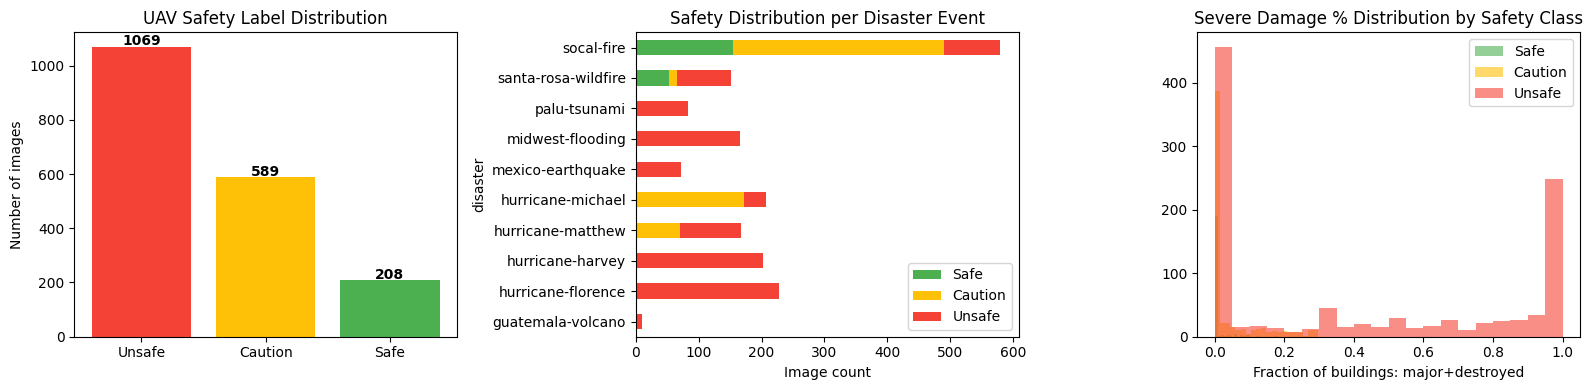

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a – Safety class distribution
counts = df['safety_label'].map(SAFETY_LABELS).value_counts()
colors = [SAFETY_COLORS[{v: k for k, v in SAFETY_LABELS.items()}[c]] for c in counts.index]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('UAV Safety Label Distribution')
axes[0].set_ylabel('Number of images')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 4b – Safety class per disaster event
pivot = df.groupby(['disaster', 'safety_label']).size().unstack(fill_value=0)
pivot.columns = [SAFETY_LABELS[c] for c in pivot.columns]
pivot.plot(kind='barh', stacked=True, ax=axes[1],
           color=[SAFETY_COLORS[k] for k in SAFETY_LABELS],
           legend=True)
axes[1].set_title('Safety Distribution per Disaster Event')
axes[1].set_xlabel('Image count')
axes[1].legend(loc='lower right')

# 4c – Pct severe damage vs safety label
for label_id, label_name in SAFETY_LABELS.items():
    subset = df[df['safety_label'] == label_id]['pct_severe']
    axes[2].hist(subset, bins=20, alpha=0.6, label=label_name,
                 color=SAFETY_COLORS[label_id])
axes[2].set_title('Severe Damage % Distribution by Safety Class')
axes[2].set_xlabel('Fraction of buildings: major+destroyed')
axes[2].legend()

plt.tight_layout()
plt.show()

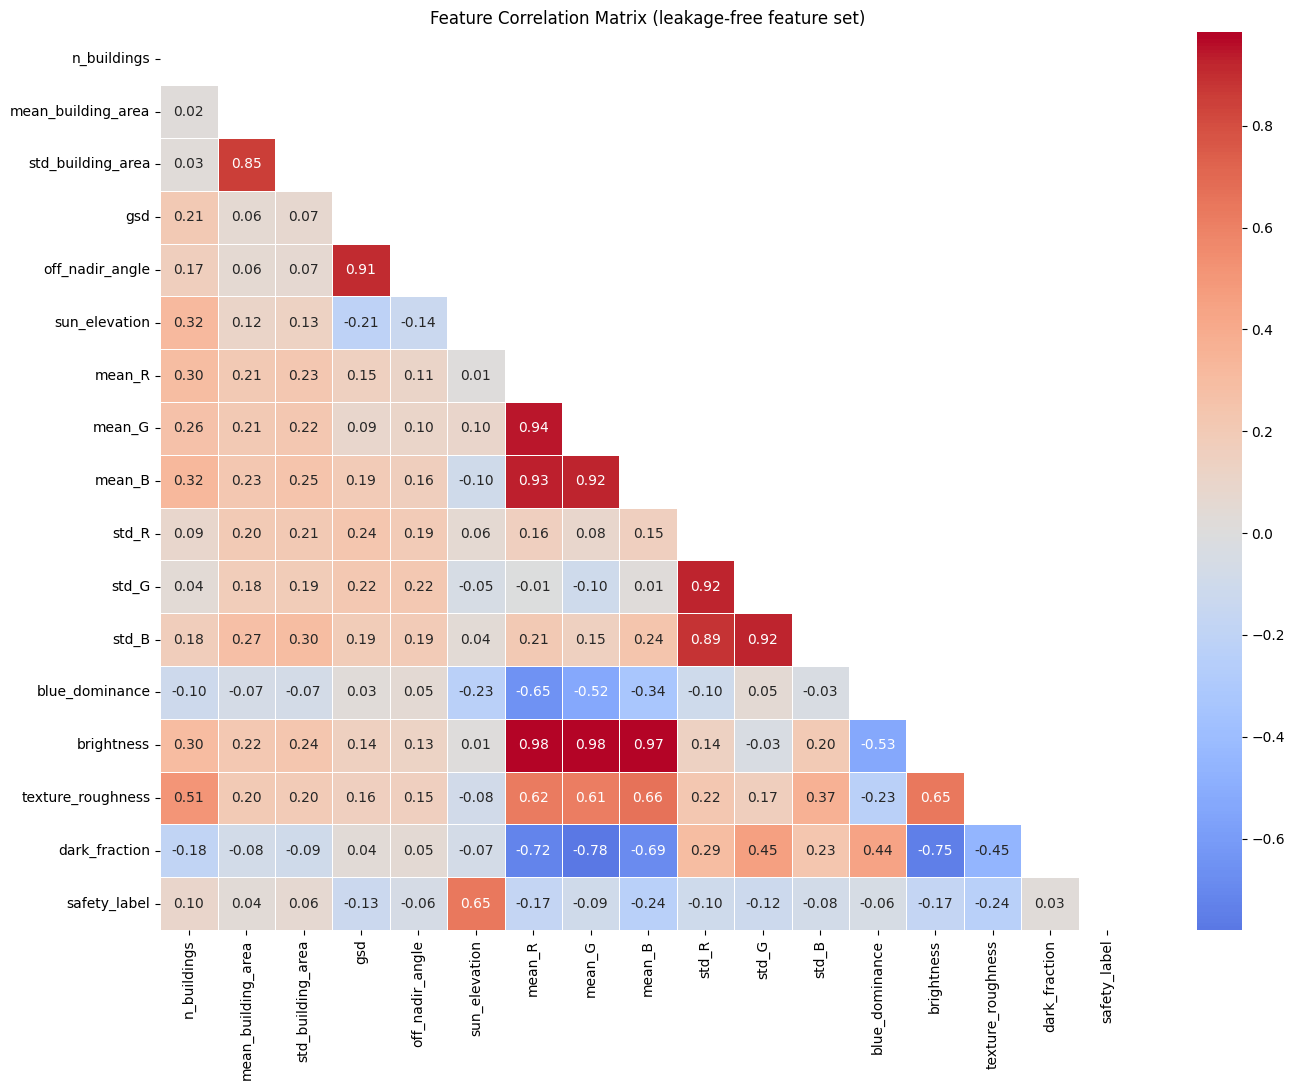


Feature correlations with safety_label:
sun_elevation         0.645023
texture_roughness     0.241809
mean_B                0.239620
mean_R                0.172243
brightness            0.169895
gsd                   0.126582
std_G                 0.115534
std_R                 0.100402
n_buildings           0.099558
mean_G                0.091218
std_B                 0.082340
std_building_area     0.063622
off_nadir_angle       0.058220
blue_dominance        0.055946
mean_building_area    0.038701
dark_fraction         0.026889


In [43]:
# Features the SVM is allowed to see.
# Damage-proportion columns (pct_no_damage, pct_severe, etc.) and risk_tier are
# EXCLUDED because they are used verbatim to construct the safety label — including
# them would be data leakage and produce artificially inflated scores.
FEATURE_COLS = [
    # Building geometry (count/size, not damage class)
    'n_buildings', 'mean_building_area', 'std_building_area',
    # Sensor / acquisition metadata
    'gsd', 'off_nadir_angle', 'sun_elevation',
    # Visual / spectral (derived from raw pixels)
    'mean_R', 'mean_G', 'mean_B',
    'std_R',  'std_G',  'std_B',
    'blue_dominance', 'brightness', 'texture_roughness', 'dark_fraction',
]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[FEATURE_COLS + ['safety_label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax)
ax.set_title('Feature Correlation Matrix (leakage-free feature set)')
plt.tight_layout()
plt.show()

print('\nFeature correlations with safety_label:')
print(corr['safety_label'].drop('safety_label').abs().sort_values(ascending=False).to_string())

## 5. Train / Test Split

In [44]:
X = df[FEATURE_COLS].values.astype(np.float32)
y = df['safety_label'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index.values,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Train label distribution:', pd.Series(y_train).map(SAFETY_LABELS).value_counts().to_dict())
print('Test  label distribution:', pd.Series(y_test ).map(SAFETY_LABELS).value_counts().to_dict())

Train: (1492, 16)  |  Test: (374, 16)
Train label distribution: {'Unsafe': 855, 'Caution': 471, 'Safe': 166}
Test  label distribution: {'Unsafe': 214, 'Caution': 118, 'Safe': 42}


## 6. SVM Model Training

We train **two** SVM variants:

- **RBF SVM** — higher accuracy, non-linear decision boundary
- **Linear SVM** — directly interpretable feature weights → used for the justification report

Both use `StandardScaler` preprocessing and `class_weight='balanced'` to handle class imbalance.

In [45]:
scaler = StandardScaler().fit(X_train)
X_tr_s = scaler.transform(X_train)
X_te_s = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── RBF SVM via grid search ──────────────────────────────────────────────────
rbf_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    param_grid={'C': [0.1, 1, 10, 50], 'gamma': ['scale', 'auto', 0.01]},
    cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
rbf_grid.fit(X_tr_s, y_train)
rbf_model = rbf_grid.best_estimator_
print('RBF best params :', rbf_grid.best_params_)
print('RBF CV F1       :', round(rbf_grid.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
RBF best params : {'C': 10, 'gamma': 'scale'}
RBF CV F1       : 0.8578


In [46]:
# ── Linear SVM via grid search ───────────────────────────────────────────────
lin_grid = GridSearchCV(
    SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
lin_grid.fit(X_tr_s, y_train)
lin_model = lin_grid.best_estimator_
print('Linear best C   :', lin_grid.best_params_)
print('Linear CV F1    :', round(lin_grid.best_score_, 4))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Linear best C   : {'C': 10}
Linear CV F1    : 0.816


## 7. Evaluation

In [47]:
sep = '=' * 55
for name, model in [('RBF SVM', rbf_model), ('Linear SVM', lin_model)]:
    y_pred = model.predict(X_te_s)
    present = sorted(np.unique(np.concatenate([y_test, y_pred])))
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(classification_report(
        y_test, y_pred,
        labels=present,
        target_names=[SAFETY_LABELS[i] for i in present]
    ))


  RBF SVM
              precision    recall  f1-score   support

        Safe       0.57      0.79      0.66        42
     Caution       0.82      0.86      0.84       118
      Unsafe       0.96      0.86      0.90       214

    accuracy                           0.85       374
   macro avg       0.78      0.84      0.80       374
weighted avg       0.87      0.85      0.86       374


  Linear SVM
              precision    recall  f1-score   support

        Safe       0.50      0.86      0.63        42
     Caution       0.85      0.77      0.81       118
      Unsafe       0.91      0.83      0.87       214

    accuracy                           0.82       374
   macro avg       0.75      0.82      0.77       374
weighted avg       0.85      0.82      0.82       374



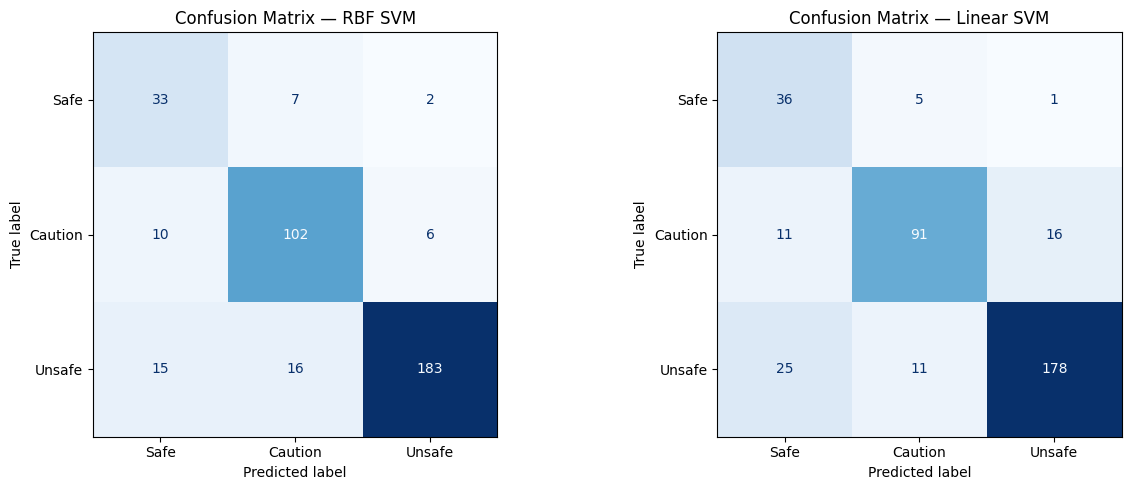

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, model) in zip(axes, [('RBF SVM', rbf_model), ('Linear SVM', lin_model)]):
    y_pred = model.predict(X_te_s)
    present = sorted(np.unique(np.concatenate([y_test, y_pred])))
    cm = confusion_matrix(y_test, y_pred, labels=present)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[SAFETY_LABELS[i] for i in present]
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()

In [49]:
# ROC-AUC for RBF (the more accurate model)
y_prob   = rbf_model.predict_proba(X_te_s)
present  = sorted(np.unique(y_test))
y_bin    = label_binarize(y_test, classes=list(range(len(SAFETY_LABELS))))
if y_bin.shape[1] > 1:
    auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    print(f'RBF SVM — Weighted OvR ROC-AUC: {auc:.4f}')

RBF SVM — Weighted OvR ROC-AUC: 0.9522
